In [46]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Annotated 
from pydantic import BaseModel,Field
from dotenv import load_dotenv
import operator,json

In [47]:
load_dotenv()
llm = ChatOpenAI(
    model="gpt-4o-mini"
)

In [48]:
class UpscState(TypedDict):
    eassy:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    indivisual_score:Annotated[list[int],operator.add]

class EvaluationSchema(BaseModel):
    feedback:str=Field(description="Detailed feedback for easy")   
    score:int=Field(description="Score out of 10",gt=0,le=10)
     
structuredllm = llm.with_structured_output(EvaluationSchema)
print(structuredllm)

first=_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14', 'langchain-openai': '1.4.2'}}, output_version=None, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001EF7995B100>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001EF7995AEA0>, root

In [49]:
def performAnalysisFeedback(state:UpscState)->dict:
    print(f'In [performAnalysisFeedback]')    
    prompt  = f""" 
                perform analusis and return feedback, score based on analysis for defined easy:
                {state['eassy']}    
                """
    response = structuredllm.invoke(prompt)
    return {
        'analysis_feedback':response.feedback,
        'indivisual_score':[response.score]
    }

In [50]:
def performclarityFeedback(state:UpscState)->dict:  
    print(f'In [performclarityFeedback]')     
    prompt  = f""" 
                perform tone clarity check and return feedback, score based on clarity check for defined easy:
                {state['eassy']}    
                """     
    response = structuredllm.invoke(prompt)
    return {
        'clarity_feedback':response.feedback,
        'indivisual_score':[response.score]
    }


In [51]:
def performLanguageFeedback(state:UpscState)->dict:
    print(f'In [performLanguageFeedback]')         
    prompt  = f""" 
                    perform langauage check and return feedback, score based on language check check for defined easy:
                    {state['eassy']}    
                    """     
    response = structuredllm.invoke(prompt)
    return {
            'language_feedback':response.feedback,
            'indivisual_score':[response.score]
    }

In [52]:
def overall_feedback(state:UpscState)->dict: 
    print(f'In [overall_feedback]')            
    prompt  = f""" 
                perform check against all feedback returned from each 
                analysis,clarity and language check and return
                overall summarized feedback:
                language feedback{state['language_feedback']}    
                clarity feedback{state['clarity_feedback']}   
                Analysis feedback{state['analysis_feedback']}   
                """
    response = llm.invoke(prompt)
    json_response = getattr(response, "content", None) or response     
    
    return {
        'overall_feedback':json_response,
        'avg_score':round(sum(state['indivisual_score'])/len(state['indivisual_score']),2)     
    }

In [53]:
graph = StateGraph(UpscState)
graph.add_node("performAnalysisFeedback",performAnalysisFeedback)
graph.add_node("performclarityFeedback",performclarityFeedback)
graph.add_node("performLanguageFeedback",performLanguageFeedback)
graph.add_node("overall_feedback",overall_feedback)

# Fan OUT
graph.add_edge(START,"performAnalysisFeedback")
graph.add_edge(START,"performclarityFeedback")
graph.add_edge(START,"performLanguageFeedback")

# Fan IN
graph.add_edge("performAnalysisFeedback","overall_feedback")
graph.add_edge("performclarityFeedback","overall_feedback")
graph.add_edge("performLanguageFeedback","overall_feedback")

graph.add_edge("overall_feedback",END)

workflow = graph.compile()

In [54]:
sample_easy=f"""
AI in India

AI means Artificial Intelligence. It is a new technology. AI is used in many places in India. People use AI in mobile phones, computers and online apps.

AI can help people to do work easily and quickly. It is used in schools, hospitals, banks and offices. Students can use AI for learning and getting information. Doctors can also use AI to help in some medical work.

AI has some good points, but it also has some problems. Sometimes AI gives wrong information. It can also affect some jobs.

AI is growing in India. I think AI is useful if we use it carefully and correctly."""
input_state = {'eassy':sample_easy}
workflow.invoke(input_state)

In [performAnalysisFeedback]
In [performLanguageFeedback]
In [performclarityFeedback]
In [overall_feedback]


{'eassy': '\nAI in India\n\nAI means Artificial Intelligence. It is a new technology. AI is used in many places in India. People use AI in mobile phones, computers and online apps.\n\nAI can help people to do work easily and quickly. It is used in schools, hospitals, banks and offices. Students can use AI for learning and getting information. Doctors can also use AI to help in some medical work.\n\nAI has some good points, but it also has some problems. Sometimes AI gives wrong information. It can also affect some jobs.\n\nAI is growing in India. I think AI is useful if we use it carefully and correctly.',
 'language_feedback': "The text presents a clear overview of AI and its implications in India. However, there are a few grammatical errors and awkward phrasing that could be improved for better clarity. The repetition of the phrase 'AI is used' can be varied to enhance readability. Additionally, the text could benefit from more detailed examples and clearer organization of points.",


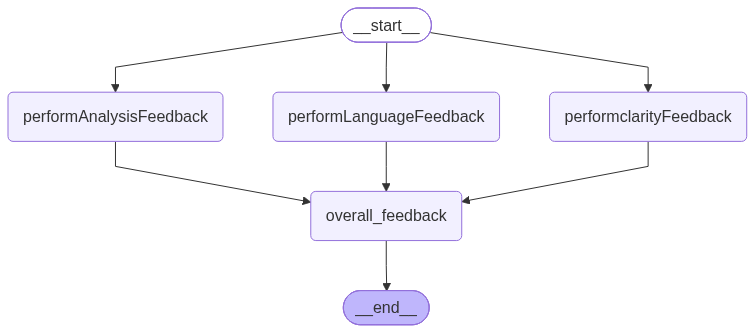

In [55]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())